# S3

In [4]:
MINIO_ENDPOINT="http://localhost:19000"
MINIO_ACCESS_KEY="minio"
MINIO_SECRET_KEY="minio123"
MINIO_BUCKET="my-demo"

CH_HOST="localhost"
CH_PORT="8123"

REDIS_HOST="localhost"
REDIS_PORT="6379"

In [5]:
import os
import io
import boto3


s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    region_name="us-east-1",
)


In [6]:
s3.create_bucket(Bucket=MINIO_BUCKET)

{'ResponseMetadata': {'RequestId': '1899B3B563A64898',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'location': '/my-demo',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '1899B3B563A64898',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '1837',
   'x-ratelimit-remaining': '1837',
   'x-xss-protection': '1; mode=block',
   'date': 'Wed, 04 Mar 2026 17:31:59 GMT'},
  'RetryAttempts': 0},
 'Location': '/my-demo'}

In [9]:
data = b"hello,s3\n1,foo\n2,bar\n"
s3.put_object(Bucket=MINIO_BUCKET, Key="example1.csv", Body=data, ContentType="text/csv")

{'ResponseMetadata': {'RequestId': '1899B3CA44FA1891',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"a8f68be6275174df96dc699b1b81be88"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': 'FWJ8Ew==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '1899B3CA44FA1891',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '1837',
   'x-ratelimit-remaining': '1837',
   'x-xss-protection': '1; mode=block',
   'date': 'Wed, 04 Mar 2026 17:33:29 GMT'},
  'RetryAttempts': 0},
 'ETag': '"a8f68be6275174df96dc699b1b81be88"',
 'ChecksumCRC32': 'FWJ8Ew==',
 'ChecksumType': 'FULL_OBJECT'}

In [20]:
resp = s3.list_objects_v2(Bucket=MINIO_BUCKET)
print("Objects:", [x["Key"] for x in resp.get("Contents", [])])

Objects: ['example.csv', 'example1.csv', 'images/picture.jpg', 'img1/curl_picture.jpg', 'my_picture.jpg']


In [ ]:
obj = s3.get_object(Bucket=MINIO_BUCKET, Key="hello.csv")
# print("File content:\n", obj["Body"].read().decode("utf-8"))

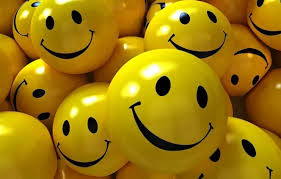

In [13]:
import requests
from PIL import Image
from io import BytesIO
import boto3
import os
from IPython.display import display

url_picture = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSzS_kmLt52y3tqmNbdwIxZRQ2u80hmDQKDNw&s"

resp = requests.get(url_picture)
resp.raise_for_status()

img_bytes = BytesIO(resp.content)

img = Image.open(img_bytes)
display(img)


In [15]:
img_bytes.seek(0)


s3.put_object(
    Bucket=MINIO_BUCKET,
    Key="my_picture.jpg",
    Body=img_bytes,
    ContentType="image/jpeg"
)

print("Uploaded to S3")


Uploaded to S3


In [18]:
!curl -L "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSzS_kmLt52y3tqmNbdwIxZRQ2u80hmDQKDNw&s" | tail -n 1

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11807  100 11807    0     0  43946      0 --:--:-- --:--:-- --:--:-- 44055
<Dh+иt,���(��d�����BU"!N��?��� �[�]�� �Αk�p�Ր��

In [19]:
!curl -L "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSzS_kmLt52y3tqmNbdwIxZRQ2u80hmDQKDNw&s" \
| AWS_ACCESS_KEY_ID=minio AWS_SECRET_ACCESS_KEY=minio123 AWS_DEFAULT_REGION=us-east-1 \
aws s3 cp - s3://my-demo/img1/curl_picture.jpg --endpoint-url http://localhost:19000

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11807  100 11807    0     0  65585      0 --:--:-- --:--:-- --:--:-- 65960


In [21]:
!curl http://localhost:19000/my-demo/

<?xml version="1.0" encoding="UTF-8"?>
<Error><Code>AccessDenied</Code><Message>Access Denied.</Message><BucketName>my-demo</BucketName><Resource>/my-demo/</Resource><RequestId>1899B4069727A54D</RequestId><HostId>dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8</HostId></Error>

In [37]:
import json

policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Sid": "PublicReadGetObject",
            "Effect": "Allow",
            "Principal": "*",
            "Action": ["s3:GetObject"],
            "Resource": ["arn:aws:s3:::{}/*".format(MINIO_BUCKET)],
        }
    ],
}

s3.put_bucket_policy(Bucket=MINIO_BUCKET, Policy=json.dumps(policy))
print("Bucket is now public for GET:", MINIO_BUCKET)

Bucket is now public for GET: my-demo


In [32]:
!curl http://localhost:19000/my-demo/img1/curl_picture.jpg --output img1.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   347  100   347    0     0  25387      0 --:--:-- --:--:-- --:--:-- 26692


In [36]:
from IPython.display import Image, display
import requests

url = "http://localhost:19000/my-demo/img1/curl_picture.jpg"

resp = requests.get(url)
display(Image(resp.content))

In [29]:
policy = {
  "Version": "2012-10-17",
  "Statement": [
    {
      "Effect": "Deny",
      "Principal": "*",
      "Action": "s3:GetObject",
      "Resource": f"arn:aws:s3:::{MINIO_BUCKET}/*"
    }
  ]
}
s3.put_bucket_policy(Bucket=MINIO_BUCKET, Policy=json.dumps(policy));

In [35]:
s3.delete_bucket_policy(Bucket=MINIO_BUCKET);

In [40]:
!curl "http://localhost:19000/my-demo?list-type=2"

<?xml version="1.0" encoding="UTF-8"?>
<ListBucketResult xmlns="http://s3.amazonaws.com/doc/2006-03-01/"><Name>my-demo</Name><Prefix></Prefix><KeyCount>5</KeyCount><MaxKeys>1000</MaxKeys><IsTruncated>false</IsTruncated><Contents><Key>example.csv</Key><LastModified>2026-03-04T17:33:01.309Z</LastModified><ETag>&#34;a8f68be6275174df96dc699b1b81be88&#34;</ETag><Size>21</Size><StorageClass>STANDARD</StorageClass></Contents><Contents><Key>example1.csv</Key><LastModified>2026-03-04T17:33:29.672Z</LastModified><ETag>&#34;a8f68be6275174df96dc699b1b81be88&#34;</ETag><Size>21</Size><StorageClass>STANDARD</StorageClass></Contents><Contents><Key>images/picture.jpg</Key><LastModified>2026-03-04T17:34:31.314Z</LastModified><ETag>&#34;3227ef6f11c88e08df106c6f9f7367c5&#34;</ETag><Size>11807</Size><StorageClass>STANDARD</StorageClass></Contents><Contents><Key>img1/curl_picture.jpg</Key><LastModified>2026-03-04T17:37:01.382Z</LastModified><ETag>&#34;3227ef6f11c88e08df106c6f9f7367c5&#34;</ETag><Size>11807

In [39]:
policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Sid": "PublicListBucket",
            "Effect": "Allow",
            "Principal": "*",
            "Action": ["s3:ListBucket"],
            "Resource": ["arn:aws:s3:::{}".format(MINIO_BUCKET)],
        },
        {
            "Sid": "PublicReadGetObject",
            "Effect": "Allow",
            "Principal": "*",
            "Action": ["s3:GetObject"],
            "Resource": ["arn:aws:s3:::{}/*".format(MINIO_BUCKET)],
        },
    ],
}

s3.put_bucket_policy(Bucket=MINIO_BUCKET, Policy=json.dumps(policy))

{'ResponseMetadata': {'RequestId': '1899B44B353743DC',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 204,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '1899B44B353743DC',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '1837',
   'x-ratelimit-remaining': '1837',
   'x-xss-protection': '1; mode=block',
   'date': 'Wed, 04 Mar 2026 17:42:43 GMT'},
  'RetryAttempts': 0}}

In [41]:
!curl "http://localhost:19000/my-demo?list-type=2" | xmllint --format -

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1283  100  1283    0     0  37924      0 --:--:-- --:--:-- --:--:-- 38878
<?xml version="1.0" encoding="UTF-8"?>
<ListBucketResult xmlns="http://s3.amazonaws.com/doc/2006-03-01/">
  <Name>my-demo</Name>
  <Prefix/>
  <KeyCount>5</KeyCount>
  <MaxKeys>1000</MaxKeys>
  <IsTruncated>false</IsTruncated>
  <Contents>
    <Key>example.csv</Key>
    <LastModified>2026-03-04T17:33:01.309Z</LastModified>
    <ETag>"a8f68be6275174df96dc699b1b81be88"</ETag>
    <Size>21</Size>
    <StorageClass>STANDARD</StorageClass>
  </Contents>
  <Contents>
    <Key>example1.csv</Key>
    <LastModified>2026-03-04T17:33:29.672Z</LastModified>
    <ETag>"a8f68be6275174df96dc699b1b81be88"</ETag>
    <Size>21</Size>
    <StorageClass>STANDARD</StorageClass>
  </Contents>
  <Contents>
    <Key>images/picture.jpg</Key>
    <LastModified>2026-03-04T17:34:3

## ClickHouse

In [43]:
!curl -u default:secret "http://localhost:8123/?query=SELECT%201"

1


In [46]:
import os
import pandas as pd
import clickhouse_connect

client = clickhouse_connect.get_client(
    host=os.environ.get("CH_HOST", "localhost"),
    port=int(os.environ.get("CH_PORT", "8123")),
    username=os.environ.get("CH_USER", "default"),
    password=os.environ.get("CH_PASSWORD", "secret"),
)

client.command("CREATE DATABASE IF NOT EXISTS demo")

client.command("""
CREATE TABLE IF NOT EXISTS demo.events (
  ts DateTime,
  user_id UInt64,
  event String,
  value Float64
) ENGINE = MergeTree
ORDER BY ts
""")

df = pd.DataFrame(
    {
        "ts": pd.to_datetime(["2026-02-02 10:00:00", "2026-02-02 10:01:00"]),
        "user_id": [1, 2],
        "event": ["click", "purchase"],
        "value": [0.0, 199.9],
    }
)

client.insert_df("demo.events", df)


In [48]:

out = client.query_df("""
SELECT
  toDate(ts) AS day,
  countIf(event='click') AS clicks,
  sumIf(value, event='purchase') AS revenue
FROM demo.events
GROUP BY day
ORDER BY day
""")

print(out)


         day  clicks  revenue
0 2026-02-02       3    599.7


In [47]:

out = client.query_df("""
SELECT
  *
FROM demo.events
""")

print(out)


                   ts  user_id     event  value
0 2026-02-02 10:00:00        1     click    0.0
1 2026-02-02 10:01:00        2  purchase  199.9
2 2026-02-02 10:00:00        1     click    0.0
3 2026-02-02 10:01:00        2  purchase  199.9
4 2026-02-02 10:00:00        1     click    0.0
5 2026-02-02 10:01:00        2  purchase  199.9


## Redis

In [49]:
import redis

r = redis.Redis(
    host="localhost",
    port=6379,
    db=0,
    decode_responses=True
)

print(r.ping())


True


In [50]:
r.set("user:1", "Albert")

True

In [55]:
value = r.get("user:1")
print(value)

Albert


In [65]:
r.set("a", "b", ex=2) ## sec

True

In [66]:
r.get("a")

'b'

In [69]:
r.incr("clicks")
r.incrby("clicks", 2)

print(r.get("clicks"))


15


In [68]:
r.get("clicks")

'12'

In [78]:
r.lpush("queue", "1")
r.rpush("queue", "2")


5

In [79]:
task = r.lpop("queue")
print(task)

1


In [80]:
r.lrange("queue", 0, -1)

['task2', 'task1', 'task2', '2']

In [81]:
r.hset("user:2", mapping={
    "name": "ALBERT",
    "age": 25
})

print(r.hgetall("user:2"))

{'name': 'ALBERT', 'age': '25'}


In [82]:
pub = redis.Redis()
sub = redis.Redis()

p = sub.pubsub()
p.subscribe("events")

pub.publish("events", "hello, albert")
pub.publish("events", "hello, marina")

for message in p.listen():
    print(message)


{'type': 'subscribe', 'pattern': None, 'channel': b'events', 'data': 1}
{'type': 'message', 'pattern': None, 'channel': b'events', 'data': b'hello, albert'}
{'type': 'message', 'pattern': None, 'channel': b'events', 'data': b'hello, marina'}


KeyboardInterrupt: 

In [86]:
pipe = r.pipeline()

pipe.set("a", 1)
pipe.set("b", 2)
pipe.incr("a", 3)

result = pipe.execute()

print(result)


[True, True, 4]
